<a href="https://colab.research.google.com/github/Jolusca/ProcessImagens/blob/main/Transforma%C3%A7%C3%B5es_de_intensidade_e_filtragem_espacial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Transformações de intensidade e filtragem espacial

In [33]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
#from google.colab.patches import cv2_imshow
#!git clone https://github.com/Emanueluz/aula-de-PDI-1.git

In [34]:
def colorir_maiores_objetos(imagem_binaria):

    # Converter para imagem colorida (3 canais)
    imagem_colorida = cv2.cvtColor(imagem_binaria, cv2.COLOR_GRAY2BGR)

    # Encontrar os objetos
    contornos, _ = cv2.findContours(imagem_binaria, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if len(contornos) == 0:
        print("Nenhum objeto encontrado!")
        return imagem_colorida

    # Calcular o raio de cada objeto (usando círculo circunscrito)
    objetos = []
    for contorno in contornos:
        (x, y), raio = cv2.minEnclosingCircle(contorno)
        objetos.append({
            'contorno': contorno,
            'raio': raio,
            'centro': (int(x), int(y))
        })

    # Ordenar por raio (do maior para o menor)
    objetos.sort(key=lambda x: x['raio'], reverse=True)

    # Definir as cores (BGR)
    cores = {
        1: (0, 255, 0),    # 1º lugar: VERDE
        2: (0, 255, 255),  # 2º lugar: AMARELO
        3: (0, 0, 255)     # 3º lugar: VERMELHO
    }


    # Colorir os 3 maiores objetos
    for posicao in range(1, 4):
        if posicao <= len(objetos):
            obj = objetos[posicao - 1]
            cor = cores[posicao]
            cv2.circle(imagem_colorida, obj['centro'], int(raio)*10, cor, 5)
            # Preencher o objeto com a cor
            cv2.drawContours(imagem_colorida, [obj['contorno']], -1, cor, -1)

            # Opcional: contorno em branco para destacar
            cv2.drawContours(imagem_colorida, [obj['contorno']], -1, (255, 255, 255), 2)

            # Escrever a posição no centro do objeto
            cv2.putText(imagem_colorida, f"{posicao}º",
                       (obj['centro'][0] - 15, obj['centro'][1] + 8),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 255, 255), 2)

            print(f"{posicao}º lugar: Raio = {obj['raio']:.2f} pixels")

    return imagem_colorida


## **1)** A primeira etapa do trabalho consiste em analisar e demonstrar o funcionamento das principais funções de transformação de intensidade em imagens.

Na pasta **“1”**, você encontrará duas subpastas: **“imagens originais”** e **“resultados esperados”**. Com base no conteúdo do livro *“Processamento Digital de Imagens” de Gonzalez*, especialmente no Capítulo 3.2, sua tarefa é:

* estudar as transformações de intensidade apresentadas;
* aplicá-las às imagens originais;
* identificar qual transformação é mais adequada para que cada imagem original se aproxime do respectivo resultado esperado.



### Imprimindo as imagens originais e as esperadas

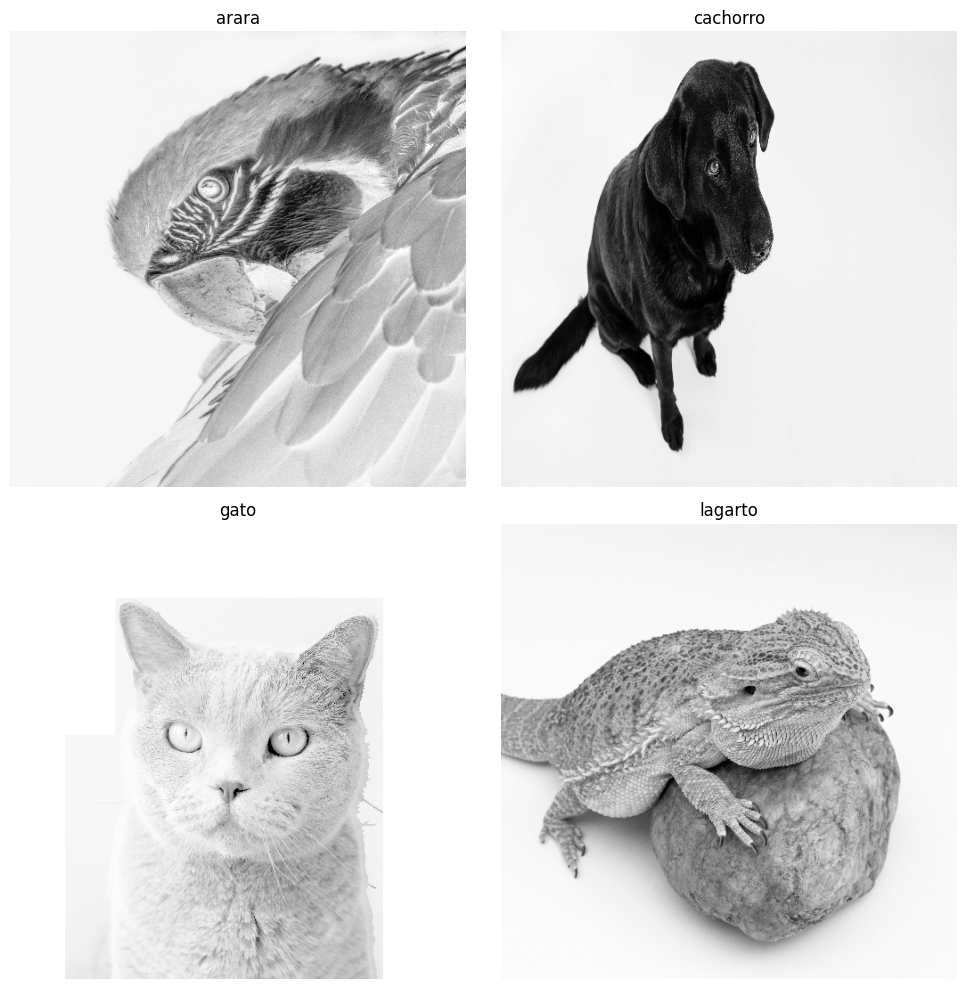

In [43]:
import cv2
import matplotlib.pyplot as plt

# 1. Caminhos e Leitura
# A flag 2 resolve o erro de 32-bit e a 0 garante escala de cinza
arara = cv2.imread('PDI/1/imagens originais/arara_ORIGINAL.png', cv2.IMREAD_UNCHANGED)
cachorro= cv2.imread("PDI/1/imagens originais/cachorro_ORIGINAL.tiff", 2 | 0)
gato = cv2.imread('PDI/1/imagens originais/gato_ORIGINAL.tiff', 2 | 0)
lagarto = cv2.imread('PDI/1/imagens originais/lagarto_ORIGINAL.jpg', 2 | 0)

# 2. Exibição
plt.figure(figsize=(10, 10))

plt.subplot(2, 2, 1)
plt.imshow(arara, cmap='gray')
plt.title('arara')
plt.axis('off')

plt.subplot(2, 2, 2)
plt.imshow(cachorro, cmap='gray')
plt.title('cachorro')
plt.axis('off')

plt.subplot(2, 2, 3)
plt.imshow(gato, cmap='gray')
plt.title('gato')
plt.axis('off')

plt.subplot(2, 2, 4)
plt.imshow(lagarto, cmap='gray')
plt.title('lagarto')
plt.axis('off')

plt.tight_layout()
plt.show()

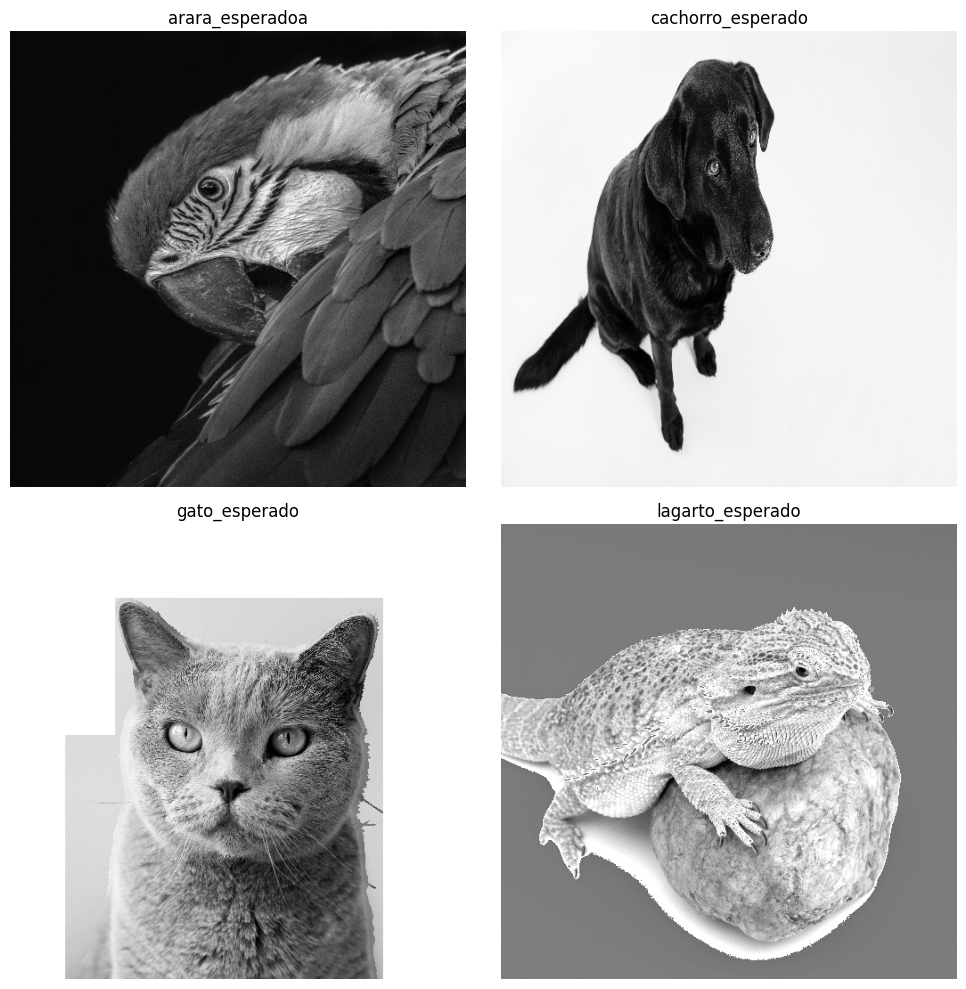

In [36]:
import cv2
import matplotlib.pyplot as plt

# 1. Caminhos e Leitura
# A flag 2 resolve o erro de 32-bit e a 0 garante escala de cinza
arara_esperado = cv2.imread('PDI/1/resultados esperados/arara_ESPERADA.png', 2 | 0)
cachorro_esperado = cv2.imread('PDI/1/resultados esperados/cachorro_ESPERADO.png', 2 | 0)
gato_esperado = cv2.imread('PDI/1/resultados esperados/gato_ESPERADO.png', 2 | 0)
lagarto_esperado = cv2.imread('PDI/1/resultados esperados/lagarto_ESPERADO.jpg', 2 | 0)

# 2. Exibição
plt.figure(figsize=(10, 10))

plt.subplot(2, 2, 1)
plt.imshow(arara_esperado , cmap='gray')
plt.title('arara_esperadoa')
plt.axis('off')

plt.subplot(2, 2, 2)
plt.imshow(cachorro_esperado, cmap='gray')
plt.title('cachorro_esperado')
plt.axis('off')

plt.subplot(2, 2, 3)
plt.imshow(gato_esperado, cmap='gray')
plt.title('gato_esperado')
plt.axis('off')

plt.subplot(2, 2, 4)
plt.imshow(lagarto_esperado, cmap='gray')
plt.title('lagarto_esperado')
plt.axis('off')

plt.tight_layout()
plt.show()

### Arara

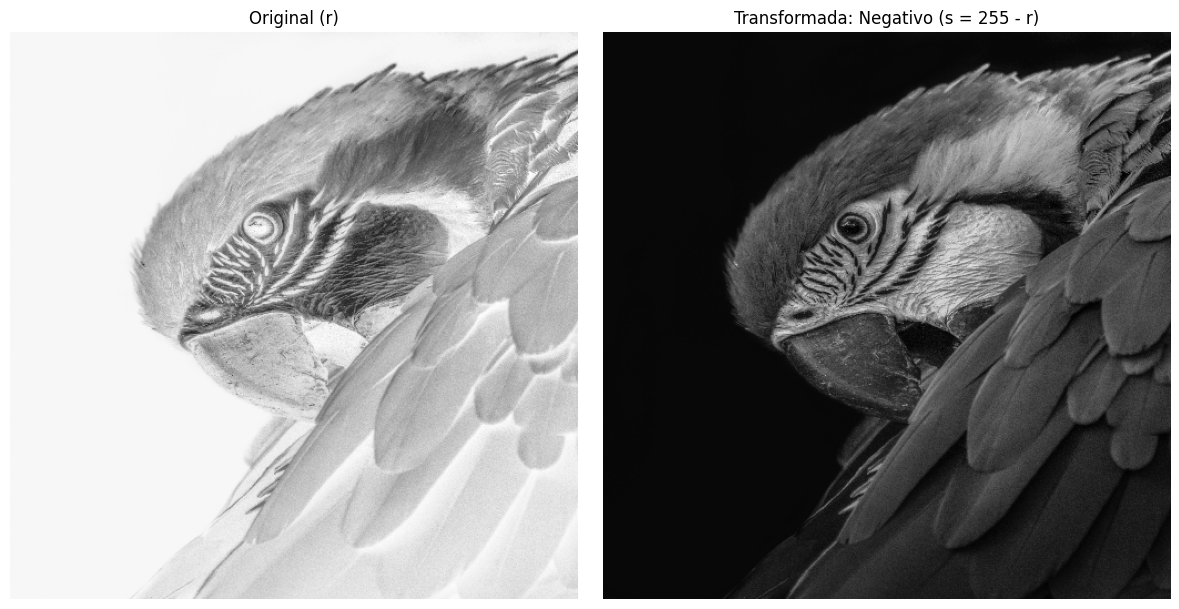

In [37]:
## ARARA Filtro negativo

# Caminho da imagem original
arara = 'PDI/1/imagens originais/arara_ORIGINAL.png'

arara_Orig = cv2.imread(arara, cv2.IMREAD_GRAYSCALE)


# 2. Aplicar a transformação de Negativo 
# s = 255 - r
arara_Neg = 255 - arara_Orig

# 3. Exibição com Matplotlib
plt.figure(figsize=(12, 6))

# Subplot para a Original
plt.subplot(1, 2, 1)
plt.imshow(arara_Orig, cmap='gray', vmin=0, vmax=255)
plt.title('Original (r)')
plt.axis('off')

# Subplot para o Negativo
plt.subplot(1, 2, 2)
plt.imshow(arara_Neg, cmap='gray', vmin=0, vmax=255)
plt.title('Transformada: Negativo (s = 255 - r)')
plt.axis('off')


plt.tight_layout()
plt.show()


### Cachorro

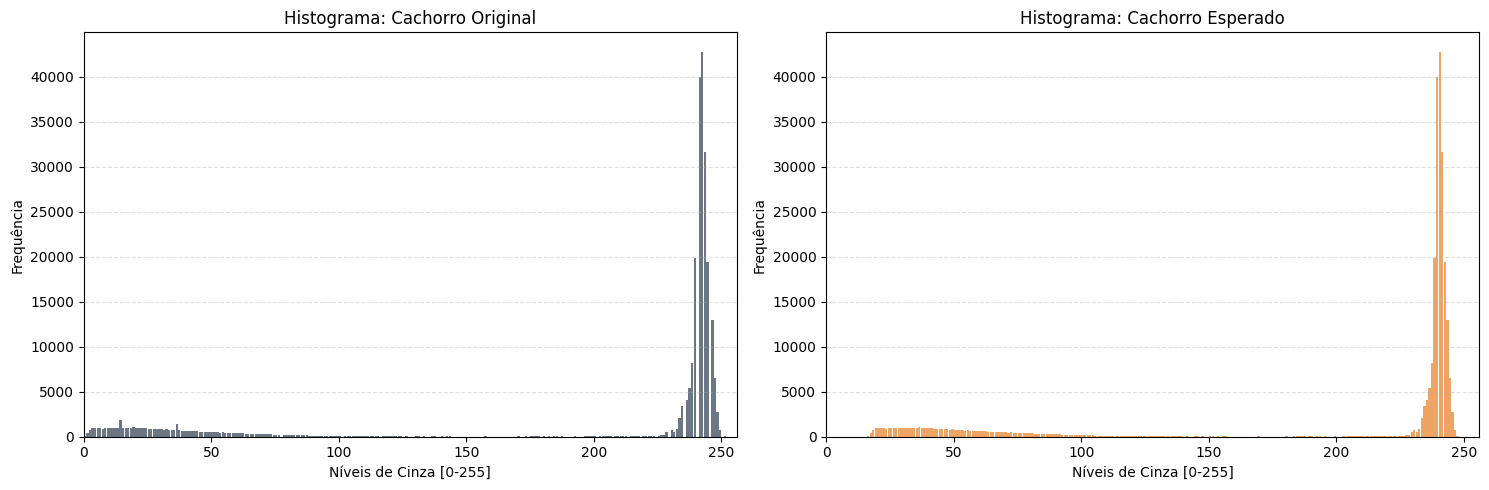

In [46]:
# 1. Normalização preventiva para ambas as imagens
if cachorro.dtype != np.uint8:
    cachorro = cv2.normalize(cachorro, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

# if cachorro_esperado.dtype != np.uint8:
#     cachorro_esperado = cv2.normalize(cachorro_esperado, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

# 2. Configuração da Figura (1 linha, 2 colunas)
plt.figure(figsize=(15, 5))

# Subplot 1: Histograma da imagem Cachorro
plt.subplot(1, 2, 1)
plt.hist(cachorro.ravel(), bins=256, range=(0, 256), color='#2c3e50', alpha=0.7, rwidth=0.9)
plt.title('Histograma: Cachorro Original')
plt.xlabel('Níveis de Cinza [0-255]')
plt.ylabel('Frequência')
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.xlim([0, 256])

# Subplot 2: Histograma da imagem Cachorro Esperado
plt.subplot(1, 2, 2)
plt.hist(cachorro_esperado.ravel(), bins=256, range=(0, 256), color='#e67e22', alpha=0.7, rwidth=0.9)
plt.title('Histograma: Cachorro Esperado')
plt.xlabel('Níveis de Cinza [0-255]')
plt.ylabel('Frequência')
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.xlim([0, 256])

plt.tight_layout()
plt.show()

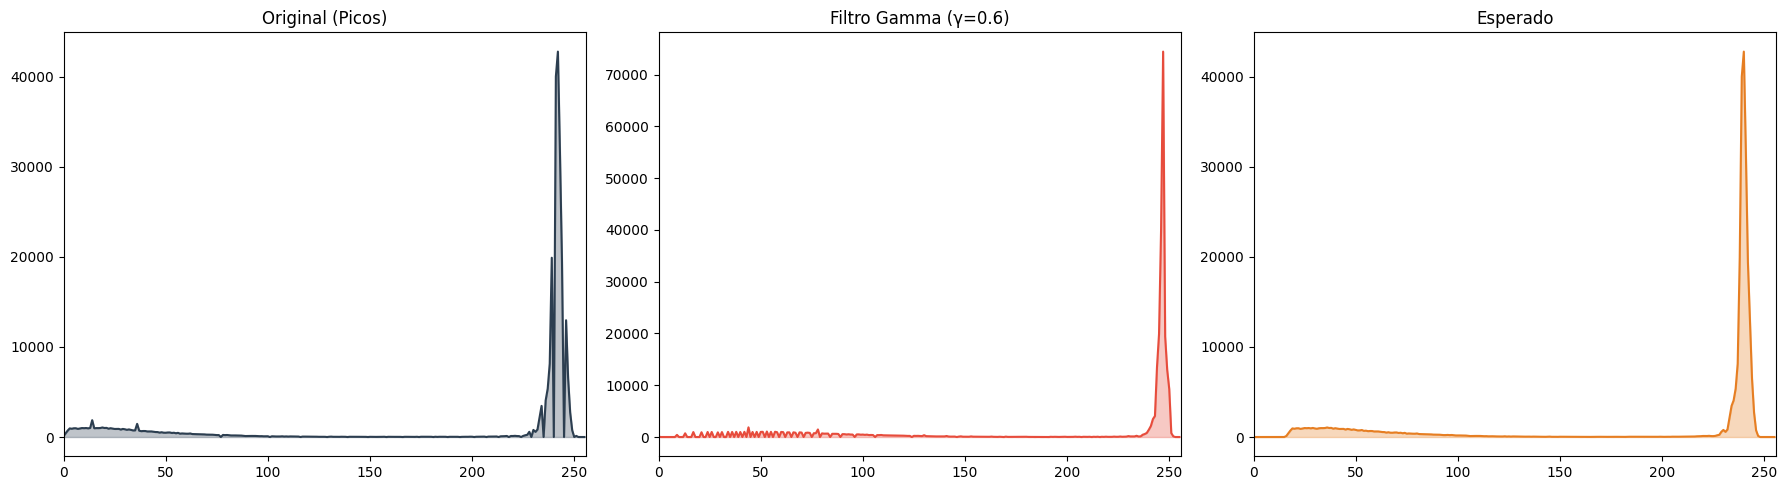

In [58]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Normalização do original (se ainda não for uint8)
if cachorro.dtype != np.uint8:
    cachorro = cv2.normalize(cachorro, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

# 2. Aplicação do Filtro Gamma
# s = c * r^gamma
# Para clarear suavemente, tente gamma entre 0.4 e 0.9
# Para escurecer e ganhar contraste, tente gamma > 1.0
gamma = 0.6
cachorro_gamma = np.array(255 * (cachorro / 255) ** gamma, dtype='uint8')

# 3. Calcular Histogramas via OpenCV
hist_original = cv2.calcHist([cachorro], [0], None, [256], [0, 256])
hist_gamma = cv2.calcHist([cachorro_gamma], [0], None, [256], [0, 256])
hist_esperado = cv2.calcHist([cachorro_esperado], [0], None, [256], [0, 256])

# 4. Plotagem
plt.figure(figsize=(18, 5))

# Original
plt.subplot(1, 3, 1)
plt.plot(hist_original, color='#2c3e50')
plt.fill_between(range(256), hist_original.flatten(), color='#2c3e50', alpha=0.3)
plt.title('Original (Picos)')
plt.xlim([0, 256])

# Gamma
plt.subplot(1, 3, 2)
plt.plot(hist_gamma, color='#e74c3c')
plt.fill_between(range(256), hist_gamma.flatten(), color='#e74c3c', alpha=0.3)
plt.title(f'Filtro Gamma (γ={gamma})')
plt.xlim([0, 256])

# Esperado
plt.subplot(1, 3, 3)
plt.plot(hist_esperado, color='#e67e22')
plt.fill_between(range(256), hist_esperado.flatten(), color='#e67e22', alpha=0.3)
plt.title('Esperado')
plt.xlim([0, 256])

plt.tight_layout()
plt.show()

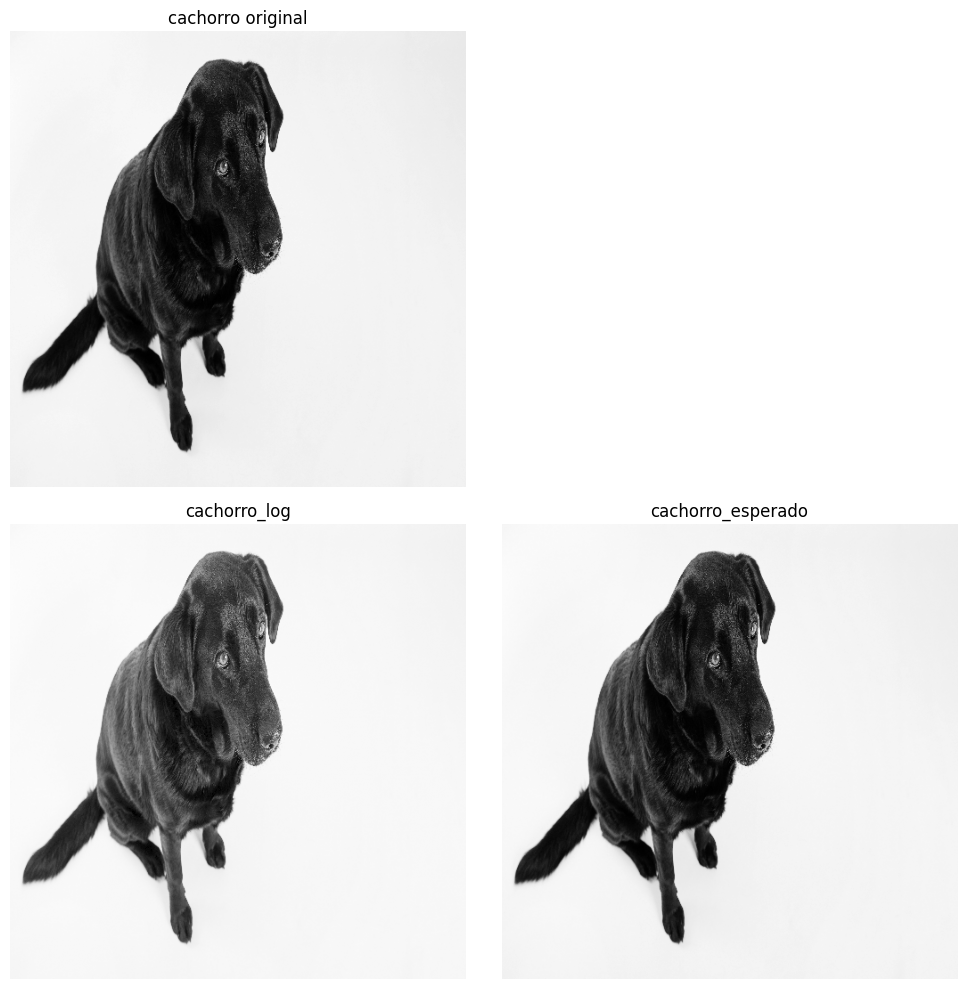

In [60]:
plt.figure(figsize=(10, 10))

plt.subplot(2, 2, 1)
plt.imshow(cachorro, cmap='gray')
plt.title('cachorro original')
plt.axis('off')

plt.subplot(2, 2, 4)
plt.imshow(cachorro_esperado, cmap='gray')
plt.title('cachorro_esperado')
plt.axis('off')

plt.subplot(2, 2, 3)
plt.imshow(cachorro_gamma, cmap='gray')
plt.title('cachorro_log')
plt.axis('off')



plt.tight_layout()
plt.show()

**2)**  Na pasta “2”, você receberá uma imagem na qual deverá utilizar a análise do histograma para orientar o processamento.

A partir dessa leitura, o objetivo é manipular a imagem de forma a destacar ou extrair as informações mais relevantes.

Durante o processo, você deve:

* analisar o histograma da imagem;
* aplicar as transformações necessárias com base nessa análise;
* registrar todas as etapas realizadas.

Todas as modificações, bem como o passo a passo completo, devem ser apresentados e plotados no arquivo do Colab.

**3)**  – Filtragem e Identificação de Objetos Astronômicos

Neste exercício, você deverá aplicar filtros de suavização e realce  na imagem "galaxa" da pasta "3" para a identificação dos maiores objetos representados na mesma.

A imagem "galaxa" contém diversos objetos astronômicos. Seu objetivo é identificar e destacar aqueles com maior comprimento.

Para padronizar a avaliação, você receberá a função ***colorir_maiores_objetos(imagem_binaria)***  (que não pode se alterada):

    colorir_maiores_objetos(imagem_binaria) → retorna uma imagem colorida destacando os 3 maiores objetos (1º = verde, 2º = amarelo, 3º = vermelho)

Regras do exercício:

    Ao final, você deve plotar a imagem original lado a lado com a imagem gerada pela função colorir_maiores_objetos.

Obrigações na resposta:

Para cada filtro aplicado, você deve explicar:

    Motivo da escolha – por que esse filtro foi necessário?

    Funcionamento – como ele opera matematicamente/processualmente?

    Expectativa – o que você esperava melhorar na imagem?

    Resultado obtido – o que realmente mudou na imagem após a aplicação?

    ⚠️ Respostas vagas ou sem relação com as imagens apresentadas serão desconsideradas.

**4)**  Este exercício é um desafio para testar o quanto você aprendeu, sua autonomia e criatividade para apresentar uma solução para um problema complexo.

Você receberá dois arquivos .dcm correspondentes a uma fatia de um exame de tomografia craniana. Deverá mostrar graficamente a aplicação de técnicas para realçar as características da imagem. Não há nenhuma limitação para realizar este exercício. Serão avaliadas a lógica aplicada e a compreensão dos processos de acesso, representação e modificação das imagens.

O exercício é propositalmente vago, mas tenha em mente que ele exige tudo o que foi visto nas aulas até agora, tratando-se de um problema comum para quem trabalha com imagens.

Para ajudar, sem resolver o problema, pense e pesquise sobre o pré-processamento necessário para que um arquivo .dcm se torne uma imagem digital passível de processamento, antes de qualquer manipulação.